# **📊 Análisis del Lenguaje con Técnicas de NLP**

## **Introducción**
En este trabajo práctico vamos a aplicar técnicas de **Procesamiento de Lenguaje Natural (NLP)** para analizar un corpus de texto.  
El objetivo es transformar el texto en representaciones numéricas que permitan extraer información útil y patrones.  
Trabajaremos con:
- **Stopwords** (eliminación de palabras irrelevantes)
- **Lematización** (reducir palabras a su forma base)
- **TF-IDF** (Term Frequency – Inverse Document Frequency)
- **Visualización de frecuencias**

---

## **1. Importamos librerias que vamos a usar**


In [1]:
import re # Importamos re (expresiones regulares) para extraer el texto entre comillas
import nltk # Importamos nltk para procesamiento del lenguaje natural
from nltk.corpus import stopwords # Desde nltk.corpus importamos stopwords para eliminar palabras irrelevantes
from nltk.tokenize import word_tokenize # Desde nltk.takenize importamos word_takenize para separar el texto en palabras individuales
from nltk.stem import WordNetLemmatizer  #Desde nltk.stem importamos wordnetlemmatizer para reducir palabras a su forma base
import string  # Importamos strings para acceder a signos de puntuacion y eliminarlos
from sklearn.feature_extraction.text import TfidfVectorizer # Desde skñearn importamos TfidVectorizer para transformar textos en numeros usando la tecnica TF-IDF
from collections import Counter  # Desde collections importamos counter para contar elementos
import matplotlib.pyplot as plt  # Importamos matplotlib para los graficos

# Descargar recursos necesarios (solo la primera vez)
#nltk.download('punkt')
#nltk.download('stopwords')
#nltk.download('wordnet')

----


## **2. Preparación del Corpus**
En esta sección cargaremos el archivo `CorpusLenguajes.txt` y mostraremos el texto original.  

In [10]:
# Abrimos y leemos el archivo
with open("CorpusLenguajes(2).txt", "r", encoding="utf-8") as f:
    corpus_text = f.readlines()

# Mostramos el corpus original
for i, linea in enumerate(corpus_text, 1):
    print(f"Oracion {i}: {linea.strip()}")


Oracion 1: corpus = [
Oracion 2: lematizar(quitarStopwords_eng(word_tokenize("Python is an interpreted and high-level language, while CPlus is a compiled and low-level language .-"))),
Oracion 3: lematizar(quitarStopwords_eng(word_tokenize("JavaScript runs in web browsers, while Python is used in various applications, including data science and artificial intelligence."))),
Oracion 4: lematizar(quitarStopwords_eng(word_tokenize("JavaScript is dynamically and weakly typed, while Rust is statically typed and ensures greater data security .-"))),
Oracion 5: lematizar(quitarStopwords_eng(word_tokenize("Python and JavaScript are interpreted languages, while Java, CPlus, and Rust require compilation before execution."))),
Oracion 6: lematizar(quitarStopwords_eng(word_tokenize("JavaScript is widely used in web development, while Go is ideal for servers and cloud applications."))),
Oracion 7: lematizar(quitarStopwords_eng(word_tokenize("Python is slower than CPlus and Rust due to its interpret


---

## **2. Limpieza del Texto**
Aplicaremos técnicas de preprocesamiento:
- Extraer el texto de cada linea
- Conversión a minúsculas
- Eliminación de signos de puntuación
- Eliminación de stopwords
- Lematización



In [3]:


#stop_words: conjunto de palabras comunes en inglés que vamos a eliminar.
stop_words = set(stopwords.words("english"))

#lemmatizer: objeto que sabe cómo reducir palabras a su raíz.
lemmatizer = WordNetLemmatizer()

#Funcion para limpiar texto(corpus)
def limpiar_texto(linea):
    # Extraemos el texto dentro de comillas
    match = re.search(r'"(.*?)"', linea)

    if match:
        # Devolvemos solo lo qeu esta adentro de las comillas y convertimos a minuscula
        texto = match.group(1).lower()

        # Dividimos el texto en palabras 
        tokens = word_tokenize(texto)

        # Recorremos el texto dividido en palabras y eliminamos signo de puntuacion y guiones
        tokens = [t for t in tokens if t not in string.punctuation and t != '-']

        # Recorremos nuevamente el texto dividido en palabras y eliminamos stop_words
        tokens = [t for t in tokens if t not in stop_words]

        # Lematizamos cada palabra
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

        # Devolvemos el texto limpio como una cadena de palabras separadas por un espacio
        return " ".join(tokens)
    
    # Si no encuentra comillas devuelve ""
    return ""

# Aplicamos limpieza a cada línea del corpus leído
corpus_limpio = [limpiar_texto(linea) for linea in corpus_text if limpiar_texto(linea)]

#Eliminamos puntos y guiones nuevamente por si quedo algo
corpus_limpio = [doc.replace(".", "").replace("-", "") for doc in corpus_limpio]

# Mostramos un ejemplo
print("Ejemplo de documento limpio:\n", corpus_limpio[0])


Ejemplo de documento limpio:
 python interpreted highlevel language cplus compiled lowlevel language 


---

## **3. Representación con TF-IDF**
Generaremos la matriz **TF-IDF**:
- Mostrar la matriz TF-IDF
- Mostrar el vocabulario generado




### **Matriz TF-IDF**

In [4]:


# Creamos el vectorizador
vectorizer = TfidfVectorizer()

# Ajustamos y transformamos el corpus limpio
tfidf_matrix = vectorizer.fit_transform(corpus_limpio)

# Mostramos la matriz TF-IDF
print("Matriz TF-IDF:\n", tfidf_matrix.toarray())


Matriz TF-IDF:
 [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.37705004 0.22390018
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.37705004
  0.         0.         0.         0.28042324 0.         0.
  0.64105397 0.         0.         0.37705004 0.         0.
  0.         0.         0.18379643 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.        ]
 [0.27225458 0.32026509 0.         0.         0.         0.32026509
  0.         0.         0.         0.         0.         0.
  0.23819059 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.32026509 0.32026509 0.         0.         0.15611609
  0.         0.         0.         0.         0.         0.
  0.         0.         0.15611609 0. 

### **Vocabulario**

In [5]:

# Mostramos el vocabulario generado
print("Vocabulario:\n", vectorizer.get_feature_names_out())

Vocabulario:
 ['application' 'artificial' 'available' 'backend' 'beginner' 'browser'
 'cloud' 'code' 'community' 'compilation' 'compiled' 'cplus' 'data'
 'development' 'due' 'dynamically' 'ecosystem' 'ensures' 'execution'
 'experienced' 'extensive' 'go' 'greater' 'highlevel' 'ideal' 'including'
 'intelligence' 'interpreted' 'java' 'javascript' 'language' 'large'
 'library' 'lowlevel' 'nature' 'nodejs' 'number' 'programmer' 'python'
 'require' 'run' 'rust' 'science' 'security' 'server' 'slower'
 'statically' 'strong' 'suitable' 'typed' 'used' 'various' 'weakly' 'web'
 'widely']


**El vocabulario es el conjunto único de palabras que el modelo detecta. Las coincidencias (repeticiones) no se agregan al vocabulario, sino que se reflejan en los valores de la matriz TF‑IDF.**

----

## 4. Análisis de Frecuencia
A partir del corpus:
- Obtener las 6 palabras más usadas
- Identificar la palabra menos utilizada
- Detectar las palabras más repetidas en la misma oración
- Imprimir el gráfico de distribución de frecuencia



---
### **6 palabras mas usadas**

In [6]:

# Unir todo el corpus en una sola lista de palabras
todas_palabras = " ".join(corpus_limpio).split()

# Contar frecuencia de cada palabra
contador = Counter(todas_palabras)

# 6 más usadas
print("Top 6 palabras:", contador.most_common(6))




Top 6 palabras: [('python', 7), ('javascript', 7), ('cplus', 5), ('rust', 5), ('interpreted', 3), ('language', 3)]


### **Palabra menos utilizada**

In [7]:
# Menos usada
print("Palabra menos usada:", contador.most_common()[-1])

Palabra menos usada: ('programmer', 1)


### **Palabras mas repetidas en la misma oracion**

In [8]:
# Detectar palabras repetidas en la misma oración
# Recorremos el corpus limpio empezando desde 1
for i, doc in enumerate(corpus_limpio, start=1):

    # eliminamos espacios
    palabras = doc.split()

    #Contamos palabras sin espacio
    contador_doc = Counter(palabras)
    
    #Creamos un diccionario con la palabra y la frecuencia solo si la frecuencia es mayor que 1
    repetidas = {p: f for p, f in contador_doc.items() if f > 1}

    # Si ahy repetidas devolemos la palabra y la cantidad
    if repetidas:
        print(f"Oracion {i}: Palabras repetidas -> {repetidas}")
    else:
    
    #Si no ahy repetidas devolvemos la palabra y una cadena que nos indica que no ahy repetidas
        print(f"Oracion {i}: No hay palabras repetidas")

Oracion 1: Palabras repetidas -> {'language': 2}
Oracion 2: No hay palabras repetidas
Oracion 3: Palabras repetidas -> {'typed': 2}
Oracion 4: No hay palabras repetidas
Oracion 5: No hay palabras repetidas
Oracion 6: No hay palabras repetidas
Oracion 7: No hay palabras repetidas
Oracion 8: Palabras repetidas -> {'require': 2, 'compilation': 2}
Oracion 9: No hay palabras repetidas
Oracion 10: No hay palabras repetidas


### **Grafico de distribucion de frecuencia**

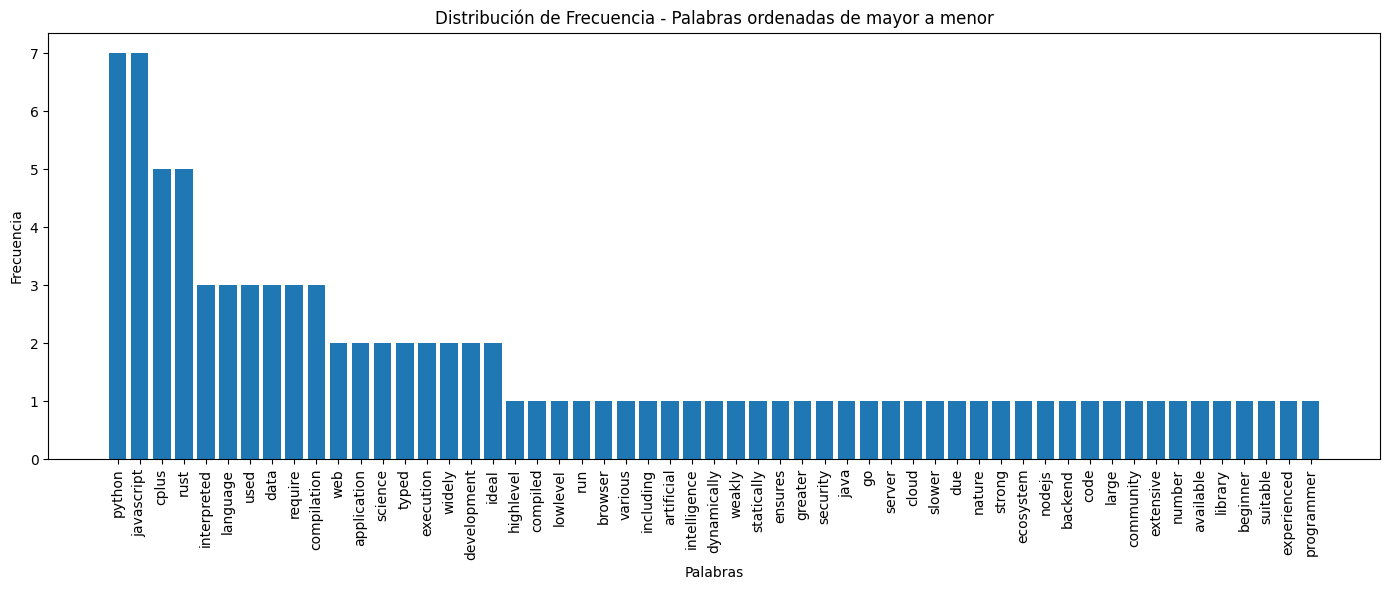

In [9]:

#  Ordenamos de mayor a menor frecuencia las palabras para el grafico
palabras_ordenadas = [p for p, f in contador.most_common()]
frecuencias_ordenadas = [f for p, f in contador.most_common()]

# Grafico con todas las palabras de mayor frecuencia a menor
plt.figure(figsize=(14,6))
plt.bar(palabras_ordenadas, frecuencias_ordenadas)
plt.title("Distribución de Frecuencia - Palabras ordenadas de mayor a menor")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")
plt.xticks(rotation=90)  # rotar etiquetas para que entren todas
plt.tight_layout()
plt.show()

---

## **📑 Informe de Conclusiones**

### **1. Palabras más usadas**
- **Python** y **JavaScript** son las más dominantes (7 apariciones cada una).  
- Les siguen **CPlus** y **Rust** (5 apariciones cada una).  
👉 Esto confirma que el corpus está centrado en comparar lenguajes de programación.

### **2. Palabra menos utilizada**
- Varias palabras aparecen solo una vez: *beginner*, *ecosystem*, *nature*, *slower*, *programmer*.  
👉 Son términos específicos que aportan matices pero no tienen peso global.

### **3. Palabras repetidas en la misma oración**
- En algunos documentos se repiten términos como **require** y **compilation**.  
👉 Esto refleja énfasis en conceptos clave sobre ejecución y compilación.

### **4. Distribución de frecuencia**
- El gráfico muestra una concentración clara en pocas palabras dominantes (Python, JavaScript, CPlus, Rust).  
- La mayoría de los términos aparecen entre 1 y 3 veces.  
👉 El corpus está diseñado para destacar comparaciones y reforzar conceptos técnicos.

### **5. Conclusiones generales**
- El corpus refleja un enfoque comparativo entre lenguajes interpretados y compilados.  
- Python y JavaScript son los más mencionados, indicando su relevancia en aplicaciones modernas.  
- Palabras como *require*, *compilation* y *interpreted* aparecen repetidamente, reforzando la temática de ejecución.  
- La distribución muestra un vocabulario balanceado: núcleo de palabras muy frecuentes + conjunto amplio de términos menos usados que aportan diversidad.

---

💡 En conjunto, el análisis de frecuencia y TF‑IDF permite concluir que el corpus está orientado a **destacar diferencias entre lenguajes de programación**, enfatizando la dicotomía entre interpretación y compilación, y resaltando la popularidad de **Python y JavaScript** en el ecosistema actual.

